# K Means


In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [6]:
X, y = make_blobs(
    n_samples= 1000,
    n_features=2,
    centers=4,
    random_state=42
)
y


array([3, 2, 2, 1, 1, 2, 1, 2, 2, 1, 1, 3, 0, 2, 2, 2, 0, 0, 0, 1, 1, 3,
       3, 3, 1, 1, 0, 0, 2, 1, 2, 2, 2, 0, 0, 3, 2, 1, 3, 3, 1, 2, 1, 3,
       1, 3, 0, 1, 3, 1, 2, 0, 1, 3, 0, 3, 0, 0, 0, 2, 2, 0, 2, 3, 1, 0,
       2, 2, 1, 0, 3, 0, 1, 2, 1, 3, 1, 0, 1, 0, 2, 0, 0, 0, 1, 3, 2, 2,
       0, 0, 0, 0, 1, 1, 3, 1, 3, 0, 1, 2, 1, 3, 3, 0, 3, 1, 1, 0, 2, 0,
       3, 2, 1, 1, 1, 1, 2, 3, 2, 1, 0, 2, 3, 1, 3, 2, 1, 3, 2, 1, 0, 2,
       1, 3, 1, 3, 0, 2, 1, 1, 0, 0, 3, 3, 3, 1, 1, 0, 0, 0, 0, 3, 2, 2,
       0, 1, 0, 1, 1, 3, 2, 0, 1, 2, 0, 0, 1, 2, 3, 2, 1, 0, 0, 1, 0, 3,
       2, 3, 2, 3, 1, 1, 0, 2, 0, 2, 1, 3, 0, 2, 1, 0, 1, 1, 0, 3, 2, 2,
       2, 3, 0, 2, 1, 0, 1, 1, 2, 0, 1, 2, 2, 3, 2, 2, 1, 0, 2, 0, 3, 1,
       3, 3, 2, 0, 3, 0, 1, 2, 2, 0, 0, 2, 0, 3, 2, 2, 3, 2, 2, 1, 2, 3,
       2, 1, 3, 0, 1, 0, 1, 1, 1, 1, 3, 1, 1, 2, 0, 2, 2, 1, 1, 1, 3, 1,
       3, 3, 2, 1, 0, 3, 1, 0, 1, 2, 0, 3, 1, 3, 2, 1, 3, 2, 3, 1, 2, 0,
       0, 2, 0, 3, 3, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2,

<Axes: >

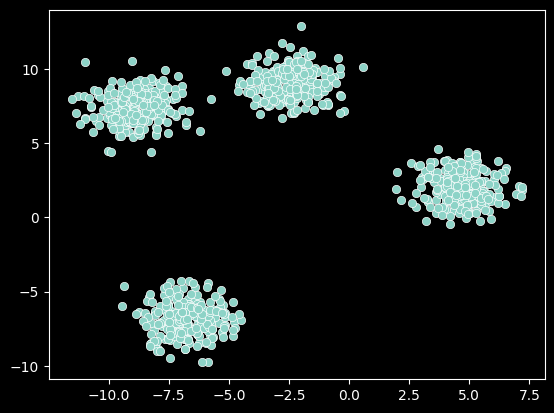

In [3]:
sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1]
)

## K - Means clustering


In [5]:
from sklearn.cluster import KMeans

In [11]:
K = 4
kmeans = KMeans(
    n_clusters=K,
    random_state=42
)

labels = kmeans.fit_predict(X)#labels = num of clusters

<Axes: >

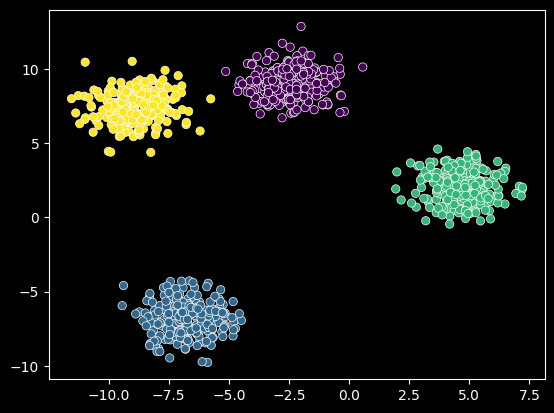

In [12]:
sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    c=labels
)

## Choose our K value

- elbow method
- silhouette method


### Elbow Method

- find Within-Cluster Sum of Squares (WCSS)


In [18]:
wcss = []

for k in range(1, 21):
    kmeans = KMeans(
        n_clusters=k,
    )
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

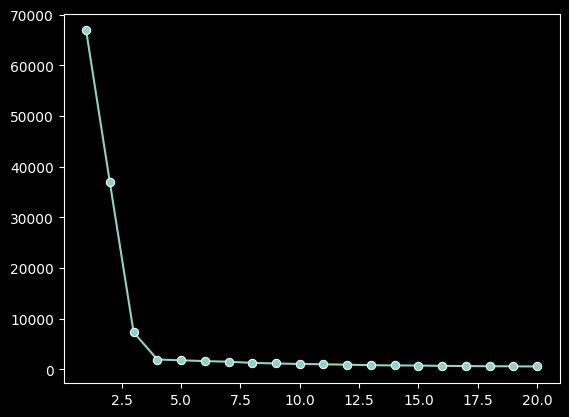

In [20]:
sns.lineplot(
    x=range(1,21),
    y=wcss,
    marker="o"
)

### automatic optimal k value finder from wcss


In [24]:
from kneed import KneeLocator
knee = KneeLocator(range(1,21), wcss, curve="convex", direction="decreasing")
print(knee.elbow)

4


## Silhouette Score


In [26]:
from sklearn.metrics import silhouette_score

ss = []

for k in range(2, 21):
    kmeans = KMeans(
        n_clusters=k
    )
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)

    ss.append(score)

<Axes: >

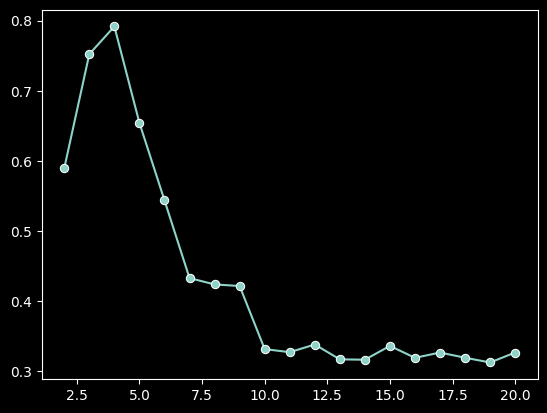

In [27]:
sns.lineplot(
    x=range(2,21),
    y=ss,
    marker="o"
)